In [4]:
#%%
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import LogLocator, FuncFormatter, LogFormatterSciNotation
import numpy as np
import math

In [5]:
"""
for each dataset
plot 
    1 graph with
        combined recall v recall
        single graph recall v recall
    1 graph with
        combined dist comp v recall
        single dist comp v recall
    1 graph with 
        overlap v efs? m?
"""

'\nfor each dataset\nplot \n    1 graph with\n        combined recall v recall\n        single graph recall v recall\n    1 graph with\n        combined dist comp v recall\n        single dist comp v recall\n    1 graph with \n        overlap v efs? m?\n'

In [6]:
def loaddata(filename):
    arr = np.loadtxt(filename, delimiter=',', skiprows=1) # d,efc,m,efs,k,recall,distcountsearch
    return { # d,efc,m,efs,k,lp50,lp99,lave,dp50,dp99,dave,hp50,hp99,have,rp50,rp99,rave
        'd':                arr[:, 0],
        'efc':              arr[:, 1],
        'm':                arr[:, 2],
        'efs':              arr[:, 3],
        'k':                arr[:, 4],
        'lp50':             arr[:, 5],
        'lp99':             arr[:, 6],
        'lave':             arr[:, 7],
        'dp50':             arr[:, 8],
        'dp99':             arr[:, 9],
        'dave':             arr[:, 10],
        'hp50':             arr[:, 11],
        'hp99':             arr[:, 12],
        'have':             arr[:, 13],
        'rp50':             arr[:, 14],
        'rp99':             arr[:, 15],
        'recall':           arr[:, 16],
    }

def loaddatam(filename):
    arr = np.loadtxt(filename, delimiter=',', skiprows=1) # d,efc,m,efs,k,recall,distcountsearch
    return { # d,efc,m,efs,k,lp50,lp99,lave,dp50,dp99,dave,hp50,hp99,have,rp50,rp99,rave
        'd':                arr[:, 0],
        'efc':              arr[:, 1],
        'm':                arr[:, 2],
        'efs':              arr[:, 3],
        'k':                arr[:, 4],
        'dcbudget':         arr[:, 5],
        'lp50':             arr[:, 6],
        'lp99':             arr[:, 7],
        'lave':             arr[:, 8],
        'dp50':             arr[:, 9],
        'dp99':             arr[:, 10],
        'dave':             arr[:, 11],
        'op50':             arr[:, 12],
        'op99':             arr[:, 13],
        'oave':             arr[:, 14],
        'rp50':             arr[:, 15],
        'rp99':             arr[:, 16],
        'recall':           arr[:, 17],
    }

In [7]:
def plot_fullbudget(datasets):
    # 1 dataset per set
    for dataset_name, dataset_fullname in datasets.items():

        # 1 param per graph
        # 1 param per graph
        metrics = {
            'lp': "latency",
            'dp': "distance_computation",
            'op': "overlap rate",
        }

        # 1 run per line >> select/load data for each line
        data = {}            
        data["hnsw"] = loaddata(f"data/hnsw-n-{dataset_fullname}-opt.txt")
        data["hnsw-m"] = loaddatam(f"data/hnsw-m-{dataset_fullname}-opt.txt")
        data["hnsw-m2"] = loaddatam(f"data/hnsw-m2-{dataset_fullname}-opt.txt")
        
        linecolor = [
            "#fc032c",
            # "#b50db2",
            # "#f06800",
            "#3600e6",
            # "#00bfe6",
            "#42f5aa",
            # "#0c6b43",
        ]

        # 2 types of lines
        lineweight = 0.7
        linestyle = ['-', ':']
        percentile = [ '50', '99' ]
        marker = 'x'

        # set x 
        xkey = "recall"
        
        # for each plot
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
        for (key,value), ax in zip(metrics.items(), (ax1, ax2, ax3)):

            # 3hird plot only shows hnsw-m and hnsw-m2
            if ax == ax3:  
                data_to_plot = {"hnsw-m": data["hnsw-m"], "hnsw-m2": data["hnsw-m2"]}
                colors_to_use = [linecolor[1], linecolor[2]]  # Skip first color
            else:  # First and second plots - show all data
                data_to_plot = data
                colors_to_use = linecolor

            # for each run = each line
            for (run, run_data), color in zip(data_to_plot.items(), colors_to_use):
                for line, perc in zip(linestyle, percentile):
                    
                    ykey = f"{key}{perc}"

                    # define x array
                    x = run_data[xkey]
                    # define y array
                    y = run_data[ykey]

                    # plot
                    ax.plot(x, y, marker=marker, color=color, label=f'{run}-p{perc}', alpha=lineweight, linestyle=line)

            plottitle = f'{dataset_name}_{value}'

            ax.set_xlabel('Recall')
            ax.set_ylabel(value)
            ax.set_title(plottitle)
            ax.legend()

        # save/show
        fig.tight_layout()
        fig.show()
        # fig.savefig(f'{plottitle}.png', dpi=300, bbox_inches='tight')

In [12]:
def plot_halfbudget(datasets):
    # 1 dataset per set
    for dataset_name, dataset_fullname in datasets.items():

        # 1 param per graph
        # 1 param per graph
        metrics = {
            'l': "latency",
            'd': "distance_computation",
            'o': "overlap rate",
        }

        # 1 run per line >> select/load data for each line
        data = {}            
        data["hnsw"] = loaddata(f"data/hnsw-n-{dataset_fullname}-opt.txt")
        data["hnsw-m3"] = loaddatam(f"data/hnsw-m3-{dataset_fullname}-opt.txt")
        data["hnsw-m4"] = loaddatam(f"data/hnsw-m4-{dataset_fullname}-opt.txt")
        
        linecolor = [
            "#fc032c",
            # "#b50db2",
            # "#f06800",
            "#3600e6",
            # "#00bfe6",
            "#42f5aa",
            # "#0c6b43",
        ]

        # 2 types of lines
        lineweights = [0.7, 0.7, 0.2]
        linestyles = ['-', ':', '-']
        percentiles = [ 'p50', 'p99', 'ave' ]
        marker = 'x'

        # set x 
        xkey = "recall"
        
        # for each plot
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
        for (key,value), ax in zip(metrics.items(), (ax1, ax2, ax3)):

            # 3hird plot only shows hnsw-m and hnsw-m2
            if ax == ax3:  
                data_to_plot = {"hnsw-m3": data["hnsw-m3"], "hnsw-m4": data["hnsw-m4"]}
                colors_to_use = [linecolor[1], linecolor[2]]  # Skip first color
            else:  # First and second plots - show all data
                data_to_plot = data
                colors_to_use = linecolor

            # for each run = each line
            for (run, run_data), color in zip(data_to_plot.items(), colors_to_use):
                for linestyle, percentile, lineweight in zip(linestyles, percentiles, lineweights):
                    
                    ykey = f"{key}{percentile}"

                    # define x array
                    x = run_data[xkey]
                    # define y array
                    y = run_data[ykey]

                    # plot
                    ax.plot(x, y, marker=marker, color=color, label=f'{run}-p{percentile}', alpha=lineweight, linestyle=linestyle)

            plottitle = f'{dataset_name}_{value}'

            ax.set_xlabel('Recall')
            ax.set_ylabel(value)
            ax.set_title(plottitle)
            ax.legend()

        # save/show
        fig.tight_layout()
        fig.show()
        # fig.savefig(f'{plottitle}.png', dpi=300, bbox_inches='tight')

In [16]:
# plot full optimization matching results
datasets = {
    'deep': "deep-image-96-angular",
    # 'gist': "gist-960-euclidean",
    'glove-100': "glove-100-angular",
    'glove-200': "glove-200-angular",
    # 'mnist': "mnist-784-euclidean",
    'nytimes': "nytimes-256-angular",
    'sift': "sift-128-euclidean",
}

C:\Users\Katherine\AppData\Local\Temp\ipykernel_14916\67708118.py:73: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


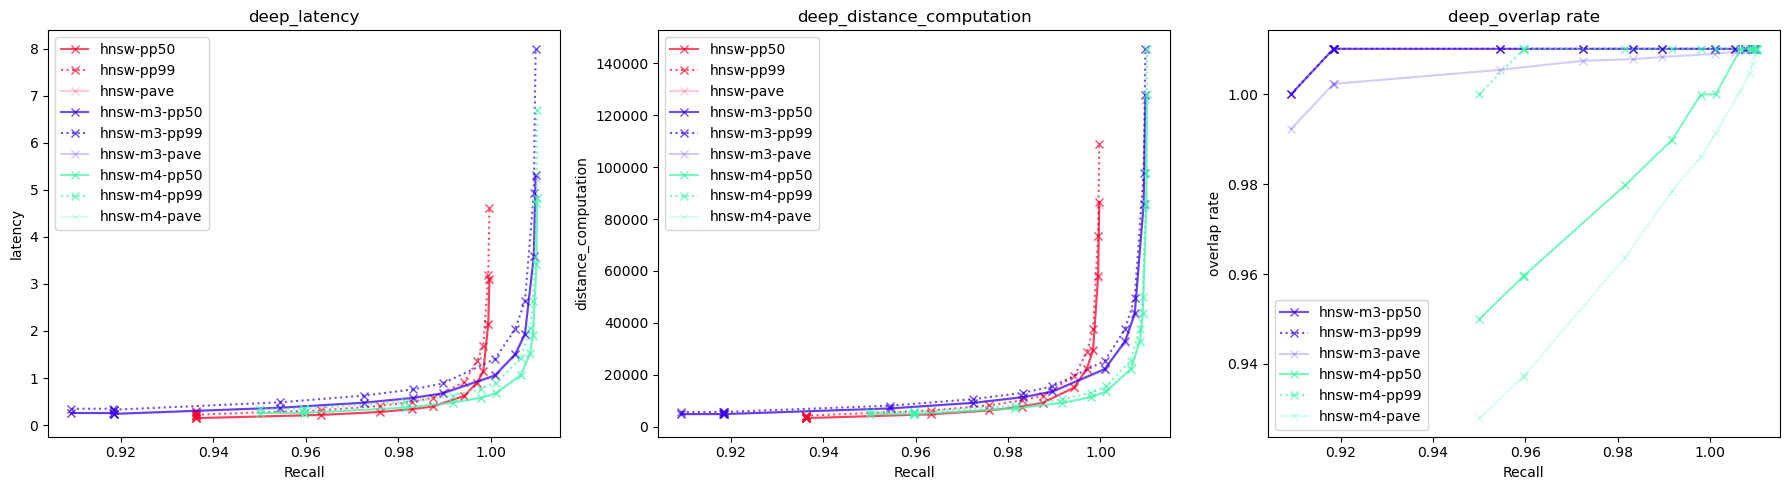

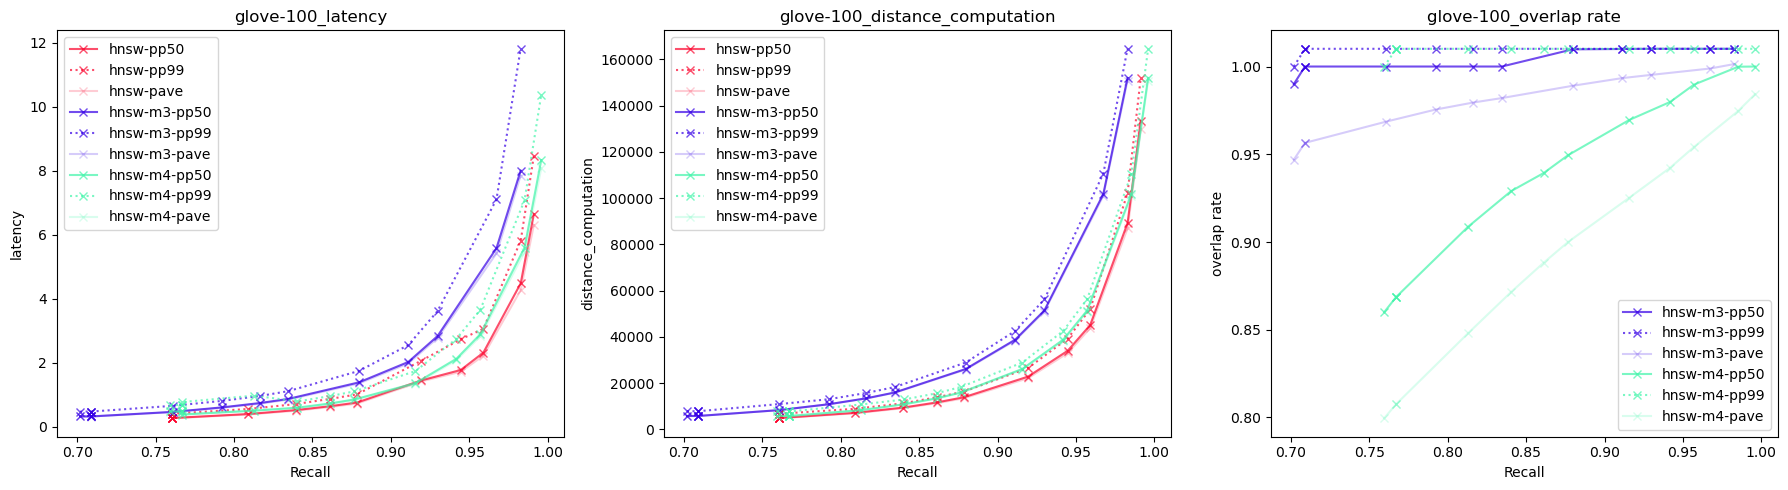

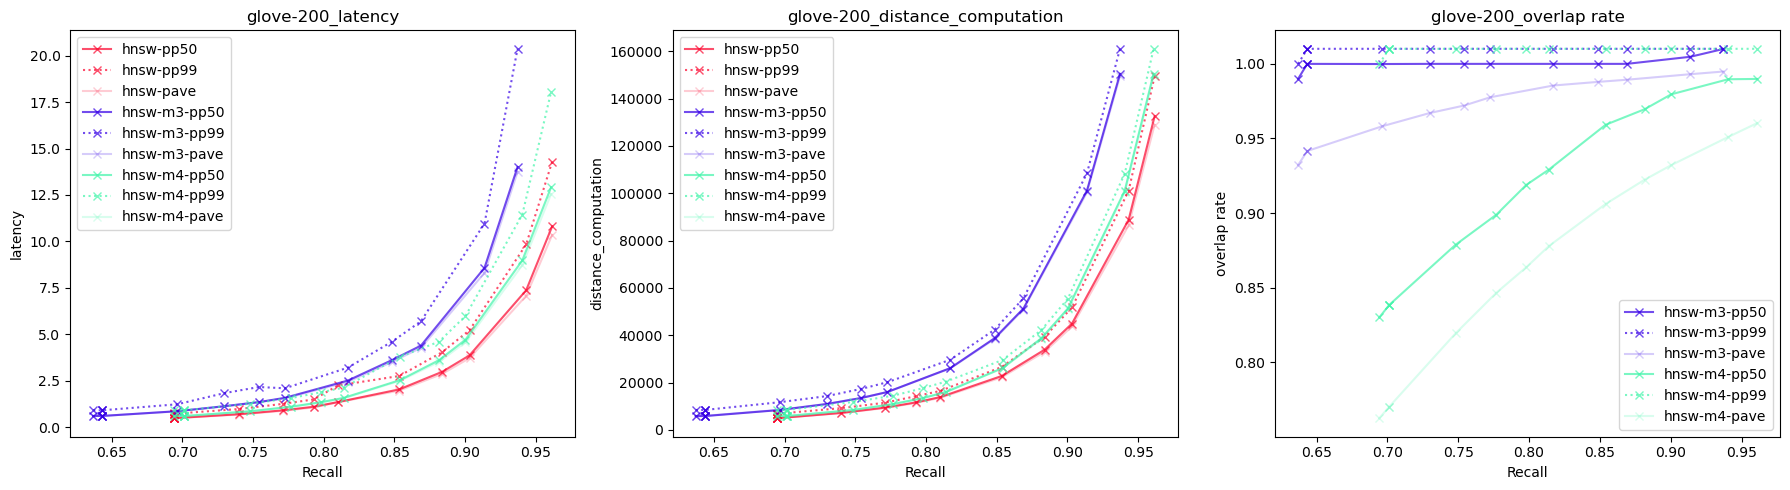

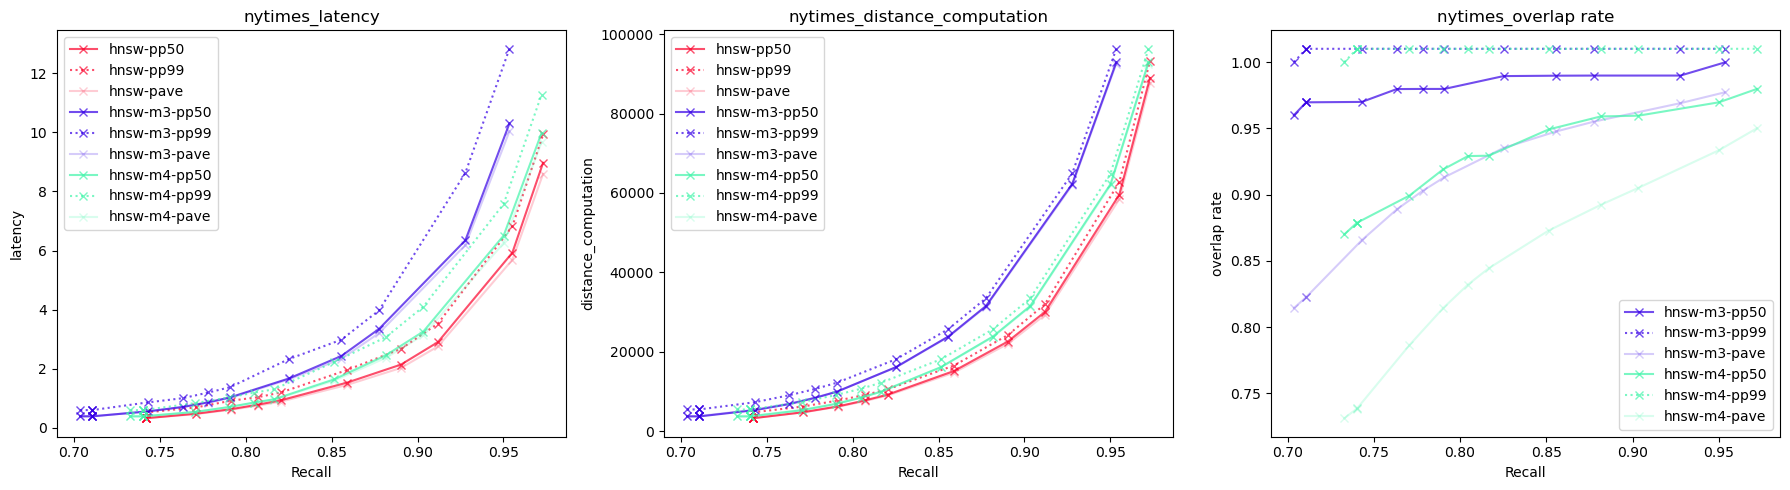

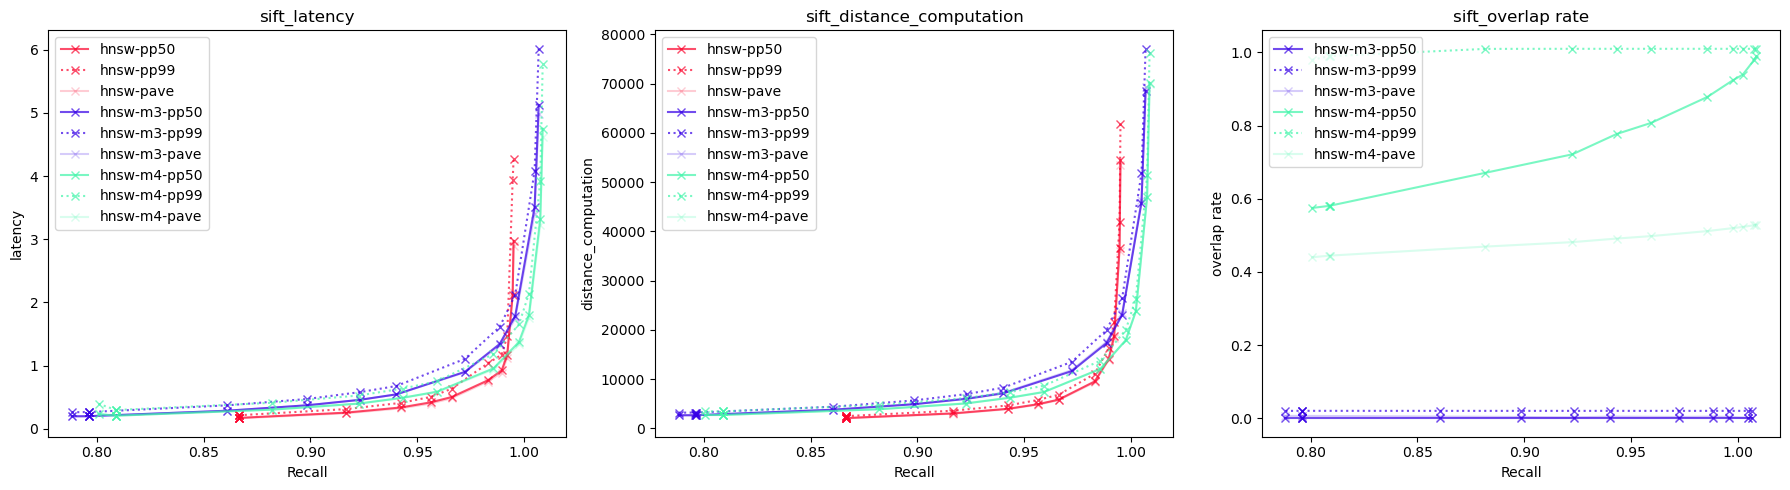

In [17]:
plot_halfbudget(datasets)

C:\Users\Katherine\AppData\Local\Temp\ipykernel_14916\3101715385.py:73: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


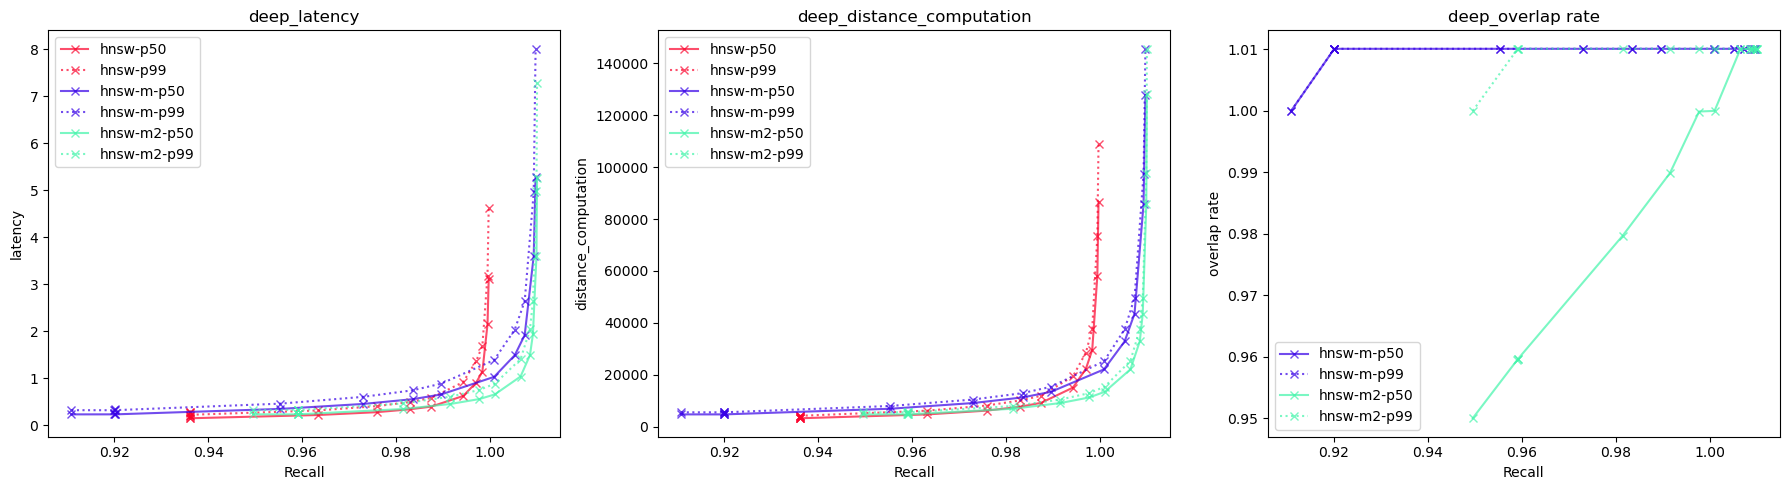

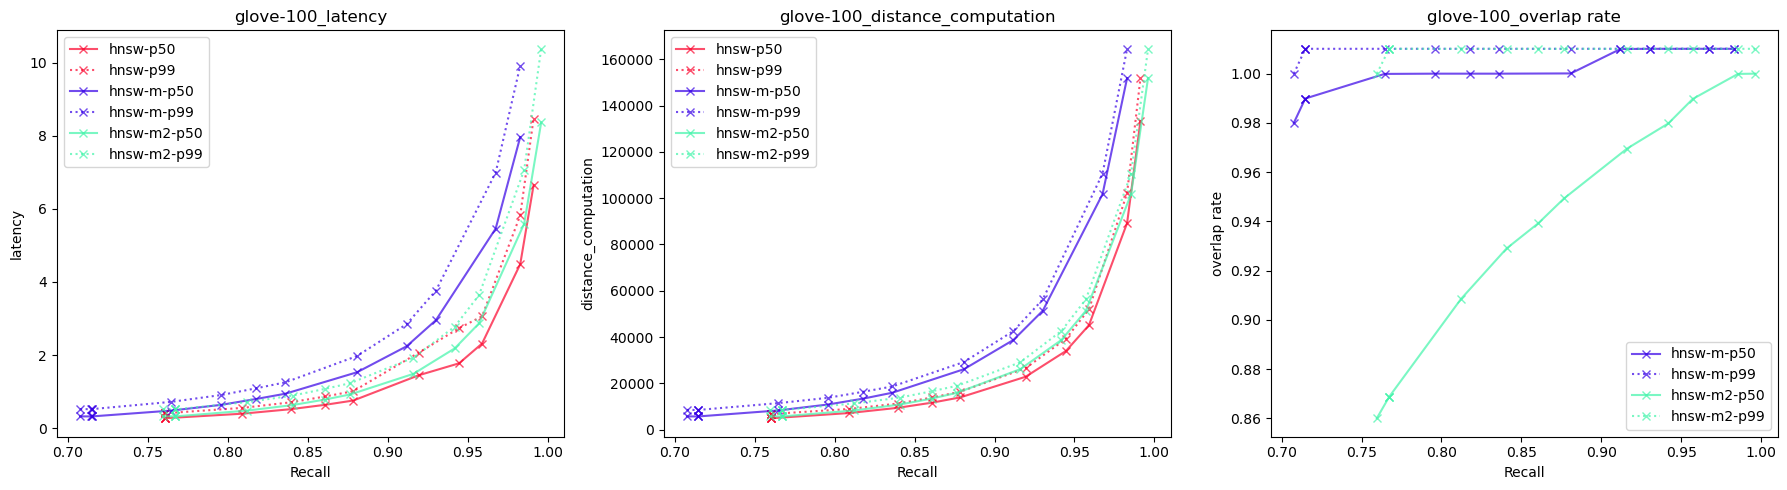

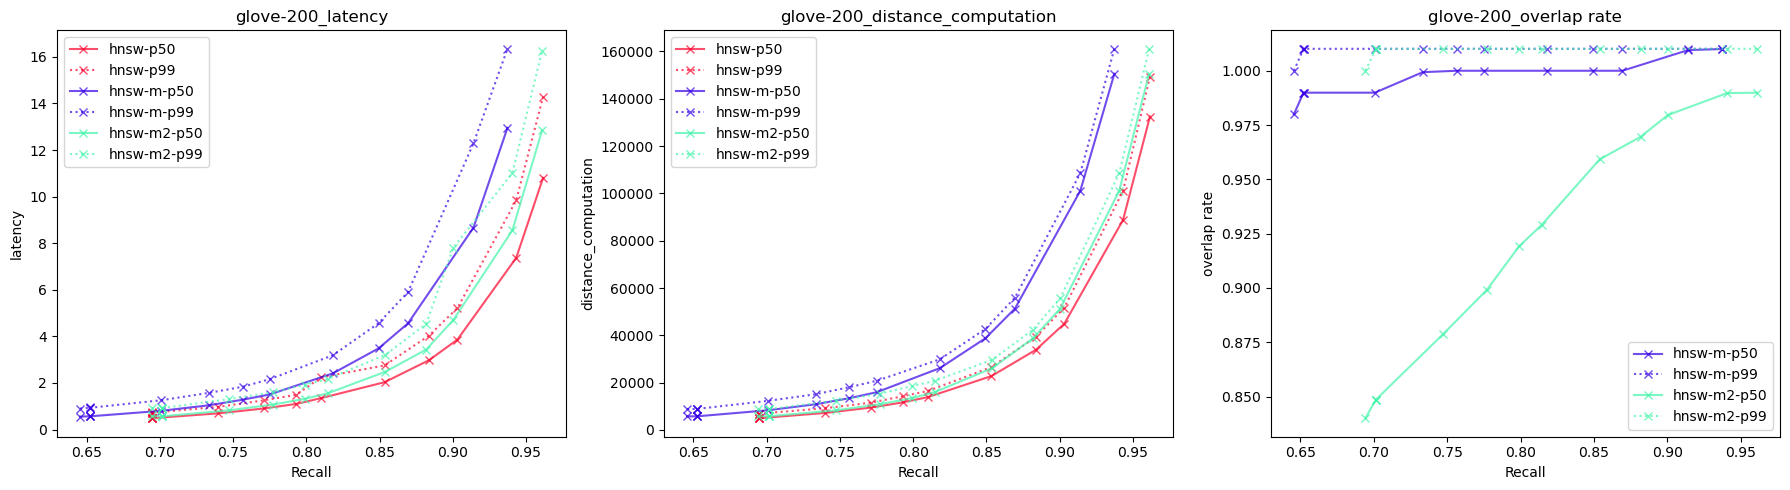

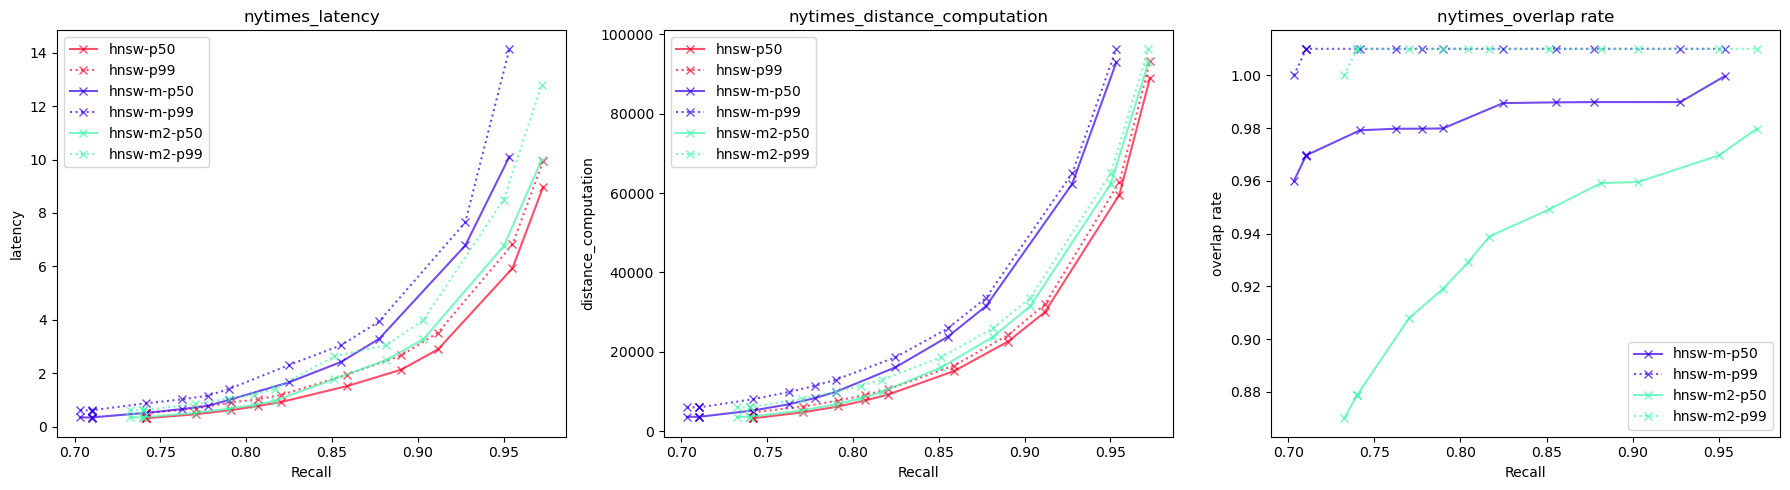

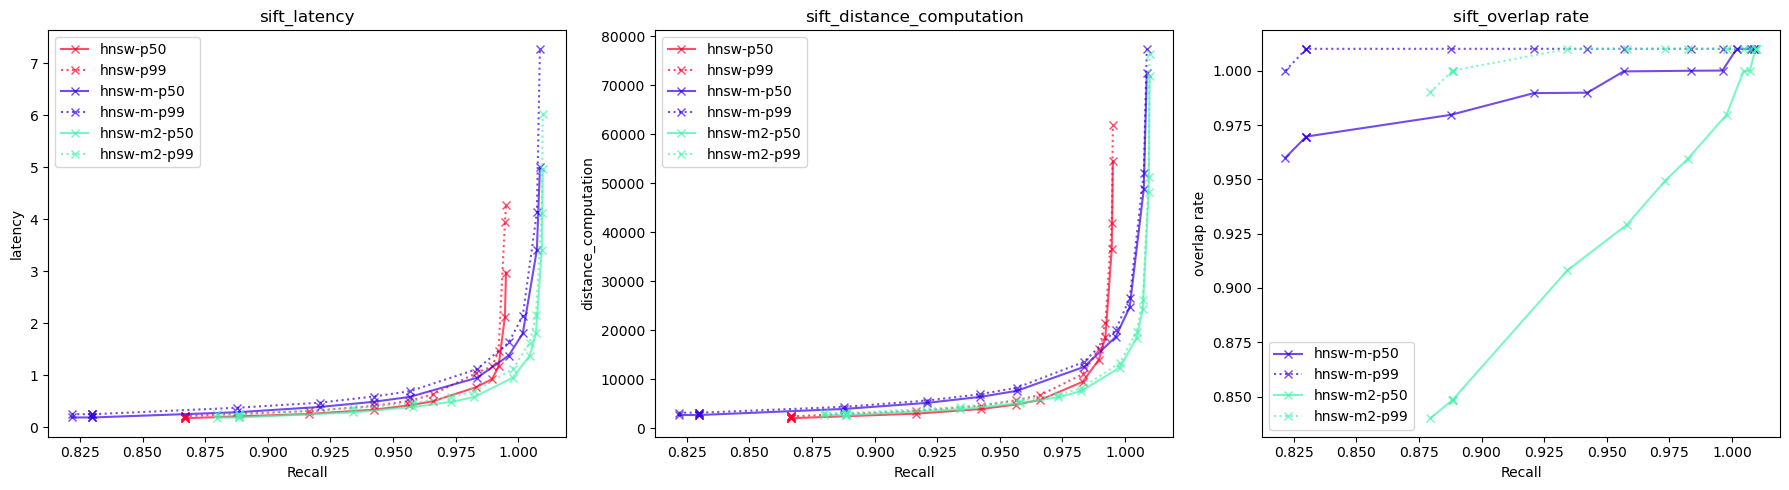

In [18]:
plot_fullbudget(datasets)